# Table of Contents

- [Initial code](#initial-code)
- [Data Generation and Visualization](#data-generation-and-visualization)
- [Data Splitting](#data-splitting)
- [Initial KNN Model and Evaluation](#initial-knn-model-and-evaluation)
- [Hyperparameter Tuning with GridSearchCV](#hyperparameter-tuning-with-gridsearchcv)
- [Evaluating the Best Model](#evaluating-the-best-model)
- [Validation Curve Plot](#validation-curve-plot)
- [kNN vs Noise](#knn-vs-noise)
- [Decision Tree vs Noise](#decision-tree-vs-noise)
- [SVM vs Noise](#svm-vs-noise)
- [Plotting Decision Boundaries](#plotting-decision-boundaries)





---



In [ ]:
# code documintation, packages
import sys
import platform
import pkgutil

import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
import joblib

print("python:", sys.version.splitlines()[0])
print("platform:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("joblib:", joblib.__version__)

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
platform: Linux-6.6.105+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
joblib: 1.5.2


In [ ]:
!pip install numpy==2.0.2
!pip install pandas==2.2.2
!pip install scikit-learn==1.6.1
!pip install matplotlib==3.10.0
!pip install seaborn==0.13.2
!pip install joblib==1.5.2



---



<a id="initial-code"></a>
### Initial code

showing the whole workflow in details before comparing the models' behaviour against noise to establish the baseline understanding


<a id="data-generation-and-visualization"></a>
### Data Generation and Visualization


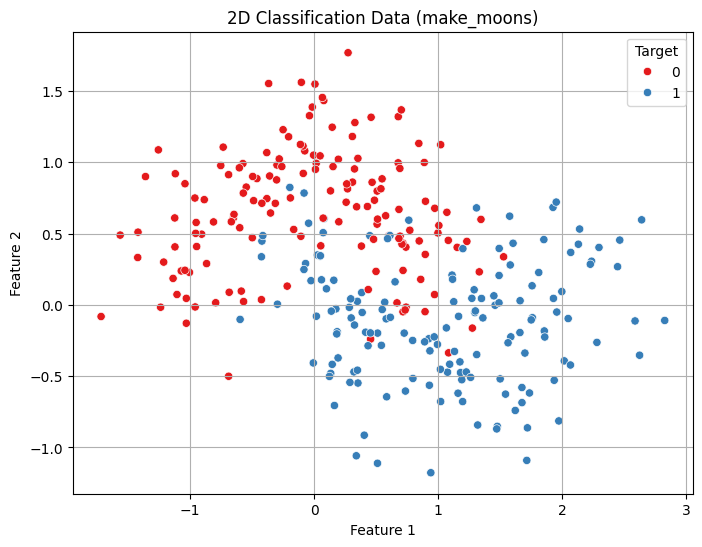

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


#generating the 2D dataset (moon, won't change aka won't be variable during experiments)
X, y = make_moons(n_samples=300, noise=0.3, random_state=42) # <- change the noise!
#reduced noise to 0.1 , for simplification? we can add more noise later
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df['Target'] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Target", palette="Set1")
plt.title("2D Classification Data (make_moons)")
plt.grid(True)
plt.show()


<a id="data-splitting"></a>
### Data Splitting


In [ ]:
#first dividing the dataset to : training , (validation+testing)
#why? i think having more data for training = the model learns more patterns, and prevents memorizing data maybe?
x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)

x_train_val = np.vstack([x_train, x_val])
y_train_val = np.hstack([y_train, y_val])


<a id="initial-knn-model-and-evaluation"></a>
### Initial KNN Model and Evaluation


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5) # this is just an initial value, then we can train/validate/test for the good enough k value
knn.fit(x_train, y_train)
# after initiallizing hte k value to 5, then we trained the model, so, next step is finding how "right" this k is!
# Predict and evaluate
y_pred = knn.predict(x_test)
print(f"Test Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")
# we chose 0,1 noise earlier, having a 0.1 noise is super seperable! so yes don't panic if the accuracy is equal to 1
# if we have a noisier dataset, and we need to find the perfect k, then we'd have to test for accuracy after each k, and we'll plot that!

Test Accuracy (k=5): 1.00



<a id="hyperparameter-tuning-with-gridsearchcv"></a>
### Hyperparameter Tuning with GridSearchCV


In [ ]:
'''
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 30, 40],
    'p': [1, 2],  # p=1 for Manhattan, p=2 for Euclidean in Minkowski
    'metric': ['minkowski', 'manhattan', 'euclidean']
}  '''
# focus on one parameter! <-
param_grid = {'n_neighbors': [1,3, 5, 7, 9,11,13,15,17,19]} # eliminate even numbers to prevent ties!

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)

grid_search.fit(x_train_val, y_train_val)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'n_neighbors': 7}
Best cross-validation score: 0.9037037037037038



<a id="evaluating-the-best-model"></a>
### Evaluating the Best Model


In [ ]:
# Get the best parameters from GridSearchCV
best_params = grid_search.best_params_

# Create a KNeighborsClassifier with the best parameters
knn_best = KNeighborsClassifier(**best_params)


# Evaluate the best model using 5-fold cross-validation on the training data
# (using x_train, y_train to be consistent with how grid_search was performed)
cv_scores_best_model = cross_val_score(knn_best, x_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation accuracy for the best model (using GridSearchCV parameters): {cv_scores_best_model.mean():.4f}")
print(f"Individual cross-validation scores: {cv_scores_best_model}")

Cross-validation accuracy for the best model (using GridSearchCV parameters): 0.9042
Individual cross-validation scores: [0.9375     0.9375     0.85416667 0.91666667 0.875     ]



<a id="validation-curve-plot"></a>
### Validation Curve Plot


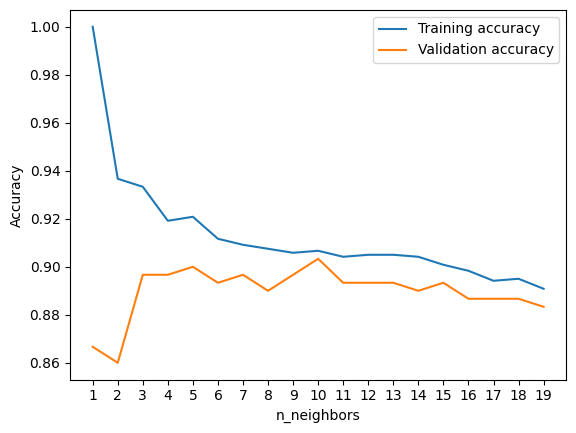

In [ ]:
param_range = np.arange(1, 20)
train_scores, val_scores = validation_curve(
    KNeighborsClassifier(),
    X, y,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

mean_train = np.mean(train_scores, axis=1)
mean_val = np.mean(val_scores, axis=1)

plt.plot(param_range, mean_train, label="Training accuracy")
plt.plot(param_range, mean_val, label="Validation accuracy")
'''
# Add horizontal lines for k=1 accuracies
plt.axhline(y=mean_train[0], color='r', linestyle=':', label='Training accuracy (k=1)')
plt.axhline(y=mean_val[0], color='g', linestyle=':', label='Validation accuracy (k=1)')
'''
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.xticks(param_range)
plt.legend()
plt.show()



---


---



---





<a id="knn-vs-noise"></a>
### kNN vs Noise


In [ ]:
def find_optimal_k_for_noise(noise_level, k_range=np.arange(1, 20)):
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)


    x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)

    # use train+val combined for GridSearchCV (cv=5 will split internally), we did that in the intial code too
    x_train_val = np.vstack([x_train, x_val])
    y_train_val = np.hstack([y_train, y_val])

    param_grid = {'n_neighbors': k_range}
    knn = KNeighborsClassifier()
    grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(x_train_val, y_train_val)

    #test set evaluation,
    best_k = grid_search.best_params_['n_neighbors']
    knn_best = KNeighborsClassifier(n_neighbors=best_k)
    knn_best.fit(x_train_val, y_train_val)
    test_score = knn_best.score(x_test, y_test)

    return best_k, test_score


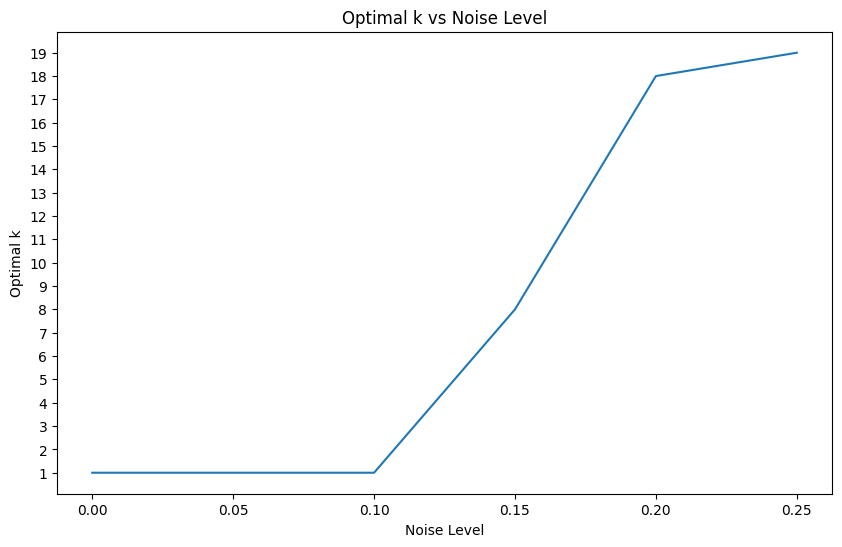

In [ ]:
noise_levels = np.arange(0.0, 0.3, 0.05) # Changed to use arange for 0.1 steps
optimal_ks = []

for noise in noise_levels:
    best_k, test_score = find_optimal_k_for_noise(noise)
    optimal_ks.append(best_k)


plt.figure(figsize=(10, 6)) # Added to set the figure size
plt.plot(noise_levels, optimal_ks)
plt.xlabel("Noise Level")
plt.ylabel("Optimal k")
plt.xticks(noise_levels) # Set x-axis ticks to the discrete noise levels
plt.yticks(np.arange(1, 20)) # Set y-axis ticks to discrete integer k values from 1 to 19
plt.title("Optimal k vs Noise Level")
plt.show()



---




<a id="decision-tree-vs-noise"></a>
### Decision Tree vs Noise


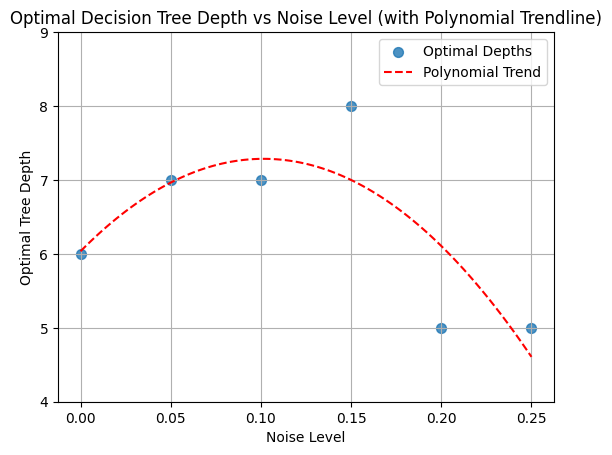

In [ ]:
def find_optimal_depth_for_noise(noise_level, depth_range=np.arange(1, 20)):
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)

    x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)
    x_train_val = np.vstack([x_train, x_val])
    y_train_val = np.hstack([y_train, y_val])


    param_grid = {'max_depth': depth_range}
    dt = DecisionTreeClassifier(random_state=42)
    grid_search = GridSearchCV(dt, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(x_train_val, y_train_val)

    best_depth = grid_search.best_params_['max_depth']
    dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
    dt_best.fit(x_train_val, y_train_val)
    test_score = dt_best.score(x_test, y_test)

    return best_depth, test_score

noise_levels = np.arange(0.0, 0.3, 0.05)
optimal_depths = []

for noise in noise_levels:
    best_depth, test_score = find_optimal_depth_for_noise(noise)
    optimal_depths.append(best_depth)

#prepare arrays for plotting
noise_levels = np.array(noise_levels)
optimal_depths = np.array(optimal_depths)

# Create a scatter plot of the original points
plt.scatter(noise_levels, optimal_depths, s=50, alpha=0.8, label="Optimal Depths")

#use a polynomial to capture the macro-level trend,unaffected as much as we can by the randomness of synthetic datasets
poly_coeffs = np.polyfit(noise_levels, optimal_depths, 2)
x_trend = np.linspace(noise_levels.min(), noise_levels.max(), 100)
y_trend = np.polyval(poly_coeffs, x_trend)

#plotting
plt.plot(x_trend, y_trend, color='red', linestyle='--', label="Polynomial Trend")
plt.xlabel("Noise Level")
plt.ylabel("Optimal Tree Depth")
plt.xticks(noise_levels)
plt.yticks(np.arange(min(optimal_depths) - 1 if len(optimal_depths) > 0 else 1, max(optimal_depths) + 2 if len(optimal_depths) > 0 else 2))
plt.title("Optimal Decision Tree Depth vs Noise Level (with Polynomial Trendline)")
plt.grid(True)
plt.legend()
plt.show()



---




<a id="svm-vs-noise"></a>
### SVM vs Noise


In [ ]:
def find_optimal_svm_params_for_noise(noise_level, c_range=np.logspace(-1, 1, 3)):
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)

    x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)
    x_train_val = np.vstack([x_train, x_val])
    y_train_val = np.hstack([y_train, y_val])

    param_grid = {'C': c_range, 'kernel': ['rbf']}
    svc = SVC(random_state=42)
    grid_search = GridSearchCV(svc, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(x_train_val, y_train_val)

    # test set evaluation
    best_params = grid_search.best_params_
    svc_best = SVC(**best_params, random_state=42)
    svc_best.fit(x_train_val, y_train_val)
    test_score = svc_best.score(x_test, y_test)

    return best_params, test_score

,noise_level,best_C,best_kernel,test_score
0,0.00,0.1,rbf,1.000000
1,0.05,0.1,rbf,1.000000
2,0.10,10.0,rbf,1.000000
3,0.15,10.0,rbf,0.996667
4,0.20,1.0,rbf,0.966667
5,0.25,1.0,rbf,0.930000


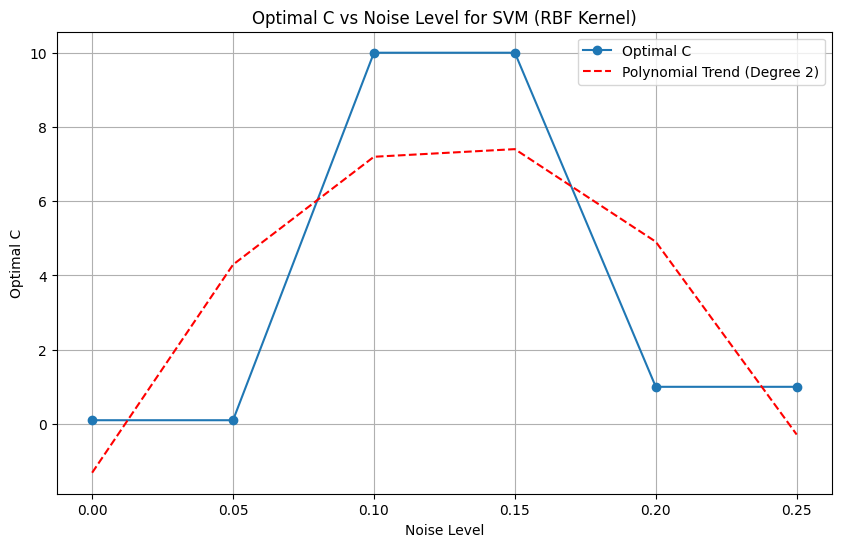

In [ ]:
noise_levels = np.arange(0.0, 0.3, 0.05)
optimal_results = []

for noise in noise_levels:
    best_params, test_score = find_optimal_svm_params_for_noise(noise)
    optimal_results.append({
        'noise_level': noise,
        'best_C': best_params['C'],
        'best_kernel': best_params['kernel'],
        'test_score': test_score
    })

results_df = pd.DataFrame(optimal_results)
display(results_df)

#plotting
plt.figure(figsize=(10, 6))
plt.plot(results_df['noise_level'], results_df['best_C'], marker='o', label='Optimal C')

# Add polynomial trend for Optimal C
degree = 2 # You can change the degree of the polynomial
coefficients_c = np.polyfit(results_df['noise_level'], results_df['best_C'], degree)
polynomial_c = np.poly1d(coefficients_c)
plt.plot(results_df['noise_level'], polynomial_c(results_df['noise_level']), linestyle='--', color='red', label=f'Polynomial Trend (Degree {degree})')

plt.xlabel("Noise Level")
plt.ylabel("Optimal C")
plt.title("Optimal C vs Noise Level for SVM (RBF Kernel)")
plt.xticks(noise_levels)
plt.grid(True)
plt.legend()
plt.show()


<a id="plotting-decision-boundaries"></a>
### Plotting Decision Boundaries



Now, let's visualize the decision boundaries for the SVM classifier at different noise levels (0.05, 0.15, 0.25). We will use the optimal `C` parameter found for each noise level to train the SVM and then plot its decision boundary over the generated data.

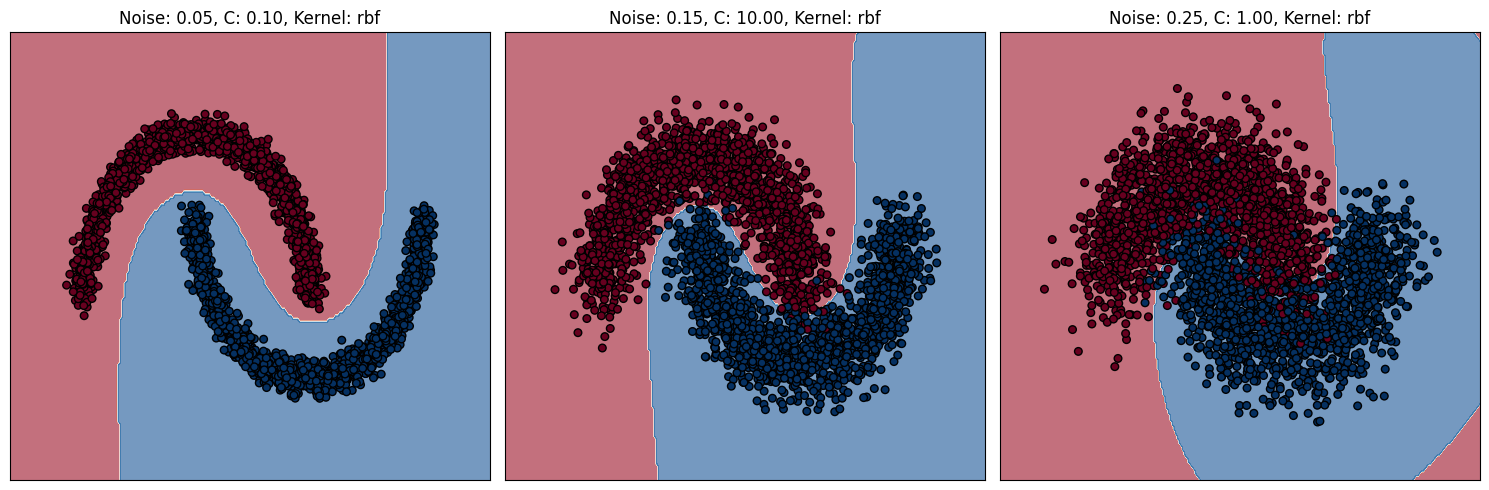

In [ ]:
def plot_decision_boundary(model, X, y, ax, title):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # step size in the mesh

    # Generate a meshgrid of points to plot decision boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.6)

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, s=30, edgecolors='k')
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

# Define the noise levels to plot
plot_noise_levels = [0.05, 0.15, 0.25]

plt.figure(figsize=(15, 5))

for i, noise_level in enumerate(plot_noise_levels):
    # Get optimal parameters for this noise level from results_df
    # Use np.isclose for robust float comparison
    optimal_row = results_df[np.isclose(results_df['noise_level'], noise_level)].iloc[0]
    best_C = optimal_row['best_C']
    best_kernel = optimal_row['best_kernel']

    # Generate data for this noise level
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)

    # Train SVM with optimal parameters
    svm_model = SVC(C=best_C, kernel=best_kernel, random_state=42)
    svm_model.fit(X, y)

    # Create subplot and plot decision boundary
    ax = plt.subplot(1, len(plot_noise_levels), i + 1)
    title = f"Noise: {noise_level}, C: {best_C:.2f}, Kernel: {best_kernel}"
    plot_decision_boundary(svm_model, X, y, ax, title)

plt.tight_layout()
plt.show()